In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
import nltk
import os

Mounted at /content/drive


# Load Data

Load data from the google drive folder **met_data**

We see that there are a few directories under the path in terms of data modality, checked the number of file types per category (pdf, doc, ppt, excel, and csv) to understand the data types we are dealing with

In [ ]:
os.listdir('/content/drive/MyDrive/met_data')

['Assignment 3 - HIS-EHR Business Functional Requirements',
 'Assignment 4 - Technical Infrastructure Diagram',
 'Lecture Material',
 'Course Project',
 'Assignment 1 - Workflow & BPR',
 'Quiz_1',
 'Assignment 2 – EHR Functional Requirements Worksheet',
 'Quiz_2',
 'Quiz_3']

In [ ]:
import os
import pandas as pd

def get_data_type(file_path):

  _, ext = os.path.splitext(file_path)
  ext = ext.lower()

  if ext in ['.doc', '.docx']:
    return "doc"
  elif ext in ['.pdf', '.pdf_']:
    return "pdf"
  elif ext in ['.xls', '.xlsx']:
    return "excel"
  elif ext == '.csv':
    return "csv"
  elif ext in ['.ppt', '.pptx']:
    return 'ppt'
  elif ext in ['.jpg', '.jpeg', '.png', '.gif']:
    return "image"
  else:
    return "unknown"

# Assuming base folder is '/content/drive/MyDrive/met_data/'
base_folder = '/content/drive/MyDrive/met_data/'

file_type_counts = {}  # Dictionary to store counts

for root, dirs, files in os.walk(base_folder):
  for file_name in files:
    file_path = os.path.join(root, file_name)
    data_type = get_data_type(file_path)

    file_type_counts[data_type] = file_type_counts.get(data_type, 0) + 1

# Print the counts for each file type
for file_type, count in file_type_counts.items():
  print(f"Number of {file_type} files: {count}")



Number of doc files: 128
Number of pdf files: 45
Number of ppt files: 33
Number of excel files: 58
Number of csv files: 1


We see that there are various types of files. So we will try to extract each file type. We will do the quiz file first representing as an excel file.

#Quiz

In [ ]:
excel = pd.read_excel('/content/drive/MyDrive/met_data/Quiz_1/24fallmetcs581_m1 Quiz 1.xlsx', sheet_name=None)

In [ ]:
for sheet_name, df_sheet in excel.items():
    print(f"Sheet Name: {sheet_name}")
    print(df_sheet.head())  # Print the first few rows of each sheet

Sheet Name: Question Details
                          Question 13 text  \
0  Question 13 additional instructor notes   
1                         Question 14 text   
2  Question 14 additional instructor notes   

  Why do we need to do Business Process Re-engineering as a part of implementing an EHR?  
0  Processes and EHR systems are tied together as...                                      
1  What is one benefit of using an Enterprise Arc...                                      
2  One of the following. Other reasonable answers...                                      
Sheet Name: Student Submissions
  Unnamed: 0                                 question 13 answer  \
0  student 1  since BPR shows and indicates the currents dat...   
1  student 2  When we look at the benefits from an IT operat...   
2  student 3  THE BENEFIT OF AN ENTREPRISE ARCHITECTURE:\n\n...   
3  student 4  One benefit of using an Enterprise Architectur...   
4  student 5  What is a Buisness Process Re-engineering

Store questions in one dataframe and answers in another dataframe

In [ ]:
import pandas as pd

# Read all sheets into a dictionary
df_dict = pd.read_excel('/content/drive/MyDrive/met_data/Quiz_1/24fallmetcs581_m1 Quiz 1.xlsx', sheet_name=None)

# Store each sheet in a separate DataFrame
for sheet_name, df_sheet in df_dict.items():
    var_name = f"df_{sheet_name.replace(' ', '_')}"
    globals()[var_name] = df_sheet
    print(f"Assigned DataFrame to: {var_name}")

Assigned DataFrame to: df_Question_Details
Assigned DataFrame to: df_Student_Submissions


We stored the questions and expected responses in one dataframe. Stored the student answers in one dataframe.

In [ ]:
df_Student_Submissions

,Unnamed: 0,question 13 answer,question 13 score,question 13 feedback,question 14 answer,question 14 score,question 14 feedback,additional feedback
0,student 1,since BPR shows and indicates the currents dat...,12 / 14,Your response covers several important points ...,Enterprise Architecture increase and enhance i...,14 / 14,Nice work!,Feedback on Short Answer Questions:\n\nQuestio...
1,student 2,When we look at the benefits from an IT operat...,14/14,Great work!,Business Process Re-engineering is very import...,14/14,Great work!,Question 13: Great work! \n\nQuestion 14: Grea...
2,student 3,THE BENEFIT OF AN ENTREPRISE ARCHITECTURE:\n\n...,2025-12-14 00:00:00,"Overall, good work! You listed several benefit...",We need to do Business Process Re-engineering ...,2025-12-14 00:00:00,You've effectively highlighted several key rea...,"Question 13: Overall, good work! You listed se..."
3,student 4,One benefit of using an Enterprise Architectur...,13/14,"Overall, good work! You effectively highlighte...",Why Business Process Re-engineering (BPR) Matt...,2025-12-14 00:00:00,You highlighted several key reasons why Busine...,"Question 13: Overall, good work! You effective..."
4,student 5,What is a Buisness Process Re-engineering ?\n\...,14/14,Nice work!,Enterprise Architecture: is a way of organizin...,14/14,Good work!,Question 13: Nice work! \n\nQuestion 14: Good ...
5,student 6,I think it is because EHR is evolving. What ma...,13/14,Great points and examples! You’re absolutely r...,"In the point of view of IT operation, the Ente...",13/14,You highlighted important benefits of Enterpri...,Question 13: Great points and examples! You’re...
6,student 7,One clear benefit of Enterprise Architecture i...,14/14,Good work!,"When implementing an EHR, a new way of providi...",14/14,Good work!,Question 13: Good work! \n\nQuestion 14: Good ...
7,student 8,"Through the businees process re-rngineering, w...",13/14,Your response addresses the importance of BPR ...,One of the benefit of using an Enterprise Arch...,13/14,"Overall, good work! It would be beneficial to ...",Question 13: Your response addresses the impor...
8,student 9,Performing a buisness re-engineering process a...,14/14,Great job!,Enterprise Achitecture provides an overarching...,14/14,Great job!,Question 13: Great job! \n\nQuestion 14: Great...
9,student 10,benefit： Better decision-making.\n\nreason： En...,2025-10-14 00:00:00,Your response highlights the benefit of EA by ...,Business Process Re-engineering (BPR) is neces...,2025-11-14 00:00:00,You identified the necessity of BPR in impleme...,Question 13: Your response highlights the bene...


In [ ]:
df_Student_Submissions.head()

,Unnamed: 0,question 13 answer,question 13 score,question 13 feedback,question 14 answer,question 14 score,question 14 feedback,additional feedback
0,student 1,since BPR shows and indicates the currents dat...,12 / 14,Your response covers several important points ...,Enterprise Architecture increase and enhance i...,14 / 14,Nice work!,Feedback on Short Answer Questions:\n\nQuestio...
1,student 2,When we look at the benefits from an IT operat...,14/14,Great work!,Business Process Re-engineering is very import...,14/14,Great work!,Question 13: Great work! \n\nQuestion 14: Grea...
2,student 3,THE BENEFIT OF AN ENTREPRISE ARCHITECTURE:\n\n...,2025-12-14 00:00:00,"Overall, good work! You listed several benefit...",We need to do Business Process Re-engineering ...,2025-12-14 00:00:00,You've effectively highlighted several key rea...,"Question 13: Overall, good work! You listed se..."
3,student 4,One benefit of using an Enterprise Architectur...,13/14,"Overall, good work! You effectively highlighte...",Why Business Process Re-engineering (BPR) Matt...,2025-12-14 00:00:00,You highlighted several key reasons why Busine...,"Question 13: Overall, good work! You effective..."
4,student 5,What is a Buisness Process Re-engineering ?\n\...,14/14,Nice work!,Enterprise Architecture: is a way of organizin...,14/14,Good work!,Question 13: Nice work! \n\nQuestion 14: Good ...


Now let's view the caveats and information of the Student submission dataframe

In [ ]:
print(f"Shape of the DataFrame: {df_Student_Submissions.shape}")

print(f"Number of Observations: {df_Student_Submissions.shape[0]}")
print(f"Number of Features: {df_Student_Submissions.shape[1]}")

print(f"Word Count of the DataFrame: {df_Student_Submissions.size}")
print(f"Total Number of Cells: {df_Student_Submissions.size}")

print("\nData Types of each column:")
print(df_Student_Submissions.dtypes)


print("\nMissing Values per column:")
print(df_Student_Submissions.isnull().sum())


print("\n## Data Exploration Summary")
print(f"- **Shape:** {df_Student_Submissions.shape[0]} rows and {df_Student_Submissions.shape[1]} columns")
print("- **Data Types:**")
for col, dtype in df_Student_Submissions.dtypes.items():
    print(f"  - {col}: {dtype}")
print("- **Missing Values:**")
for col, count in df_Student_Submissions.isnull().sum().items():
    print(f"  - {col}: {count}")

Shape of the DataFrame: (22, 8)
Number of Observations: 22
Number of Features: 8
Word Count of the DataFrame: 176
Total Number of Cells: 176

Data Types of each column:
Student                 object
question 13 answer      object
question 13 score       object
question 13 feedback    object
question 14 answer      object
question 14 score       object
question 14 feedback    object
additional feedback     object
dtype: object

Missing Values per column:
Student                 0
question 13 answer      0
question 13 score       0
question 13 feedback    0
question 14 answer      0
question 14 score       0
question 14 feedback    0
additional feedback     0
dtype: int64

## Data Exploration Summary
- **Shape:** 22 rows and 8 columns
- **Data Types:**
  - Student: object
  - question 13 answer: object
  - question 13 score: object
  - question 13 feedback: object
  - question 14 answer: object
  - question 14 score: object
  - question 14 feedback: object
  - additional feedback : obje

There are total of 22 observations and 8 columns. The 'question 13 score' and 'question 14 score' columns appear to have mixed data types (datetime and string), which might need further investigation and cleaning. There are no missing values. We can rename the column of unnamed:0 to students. Also convert the date to the score in a string format and remove any white spaces. All columns are categorical values at the moment. Let's try to also get the word count for each student's answer in question 13 and 14 and average the word count for variabality.

In [ ]:

    word_count_dict_13 = {index: len(text.split()) for index, text in df_Student_Submissions['question 13 answer'].items()}
    word_count_dict_14 = {index: len(text.split()) for index, text in df_Student_Submissions['question 14 answer'].items()}

    average_word_count_13 = sum(word_count_dict_13.values()) / len(word_count_dict_13)
    average_word_count_14 = sum(word_count_dict_14.values()) / len(word_count_dict_14)

    print("Word Count Dictionary for Question 13 student answer:", word_count_dict_13)
    print(f"Average Word Count : {average_word_count_13}")

    print(f"Word Count Dictionary:", word_count_dict_14)
    print(f"Average Word Count: {average_word_count_14}")

    print(f"Total word count for Question 13 student answer:", sum(word_count_dict_13.values()))
    print(f"Total word count for Question 14 student answer:", sum(word_count_dict_14.values()))



Word Count Dictionary for Question 13 student answer: {0: 139, 1: 122, 2: 122, 3: 167, 4: 372, 5: 163, 6: 160, 7: 98, 8: 170, 9: 31, 10: 105, 11: 222, 12: 48, 13: 44, 14: 193, 15: 109, 16: 170, 17: 66, 18: 77, 19: 98, 20: 84, 21: 40}
Average Word Count : 127.27272727272727
Word Count Dictionary: {0: 164, 1: 150, 2: 179, 3: 159, 4: 262, 5: 137, 6: 181, 7: 87, 8: 139, 9: 48, 10: 82, 11: 153, 12: 68, 13: 26, 14: 208, 15: 97, 16: 139, 17: 90, 18: 88, 19: 89, 20: 189, 21: 51}
Average Word Count: 126.63636363636364
Total word count for Question 13 student answer: 2800
Total word count for Question 14 student answer: 2786


Now we can begin cleaning this part of the data of the df_Student_Submissions

  

*   Renamed Unnamed: 0 to Student
*   Convert inaccurate datetime to the appropriate score



In [ ]:
df_Student_Submissions.rename(columns={'Unnamed: 0': 'Student', }, inplace=True)
df_Student_Submissions['question 13 score'] = df_Student_Submissions['question 13 score'].astype(str)
df_Student_Submissions['question 14 score'] = df_Student_Submissions['question 14 score'].astype(str)

def convert_datetime_to_score(datetime_str):
    return f"{int(datetime_str[5:7])}/{int(datetime_str[8:10])}" if datetime_str.startswith("2025") else datetime_str

df_Student_Submissions['question 13 score'] = df_Student_Submissions['question 13 score'].str.replace(' ', '')

df_Student_Submissions['question 14 score'] = df_Student_Submissions['question 14 score'].str.replace(' ', '')
df_Student_Submissions['question 13 score'] = df_Student_Submissions['question 13 score'].apply(lambda x: convert_datetime_to_score(x).strip())
df_Student_Submissions['question 14 score'] = df_Student_Submissions['question 14 score'].apply(lambda x: convert_datetime_to_score(x).strip())

We can check the score distributions of each question 13 and 14 with a count plot to see understand it's variability with a countplot

<ipython-input-64-09c70a006f9d>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='question 13 score', data=df_Student_Submissions,


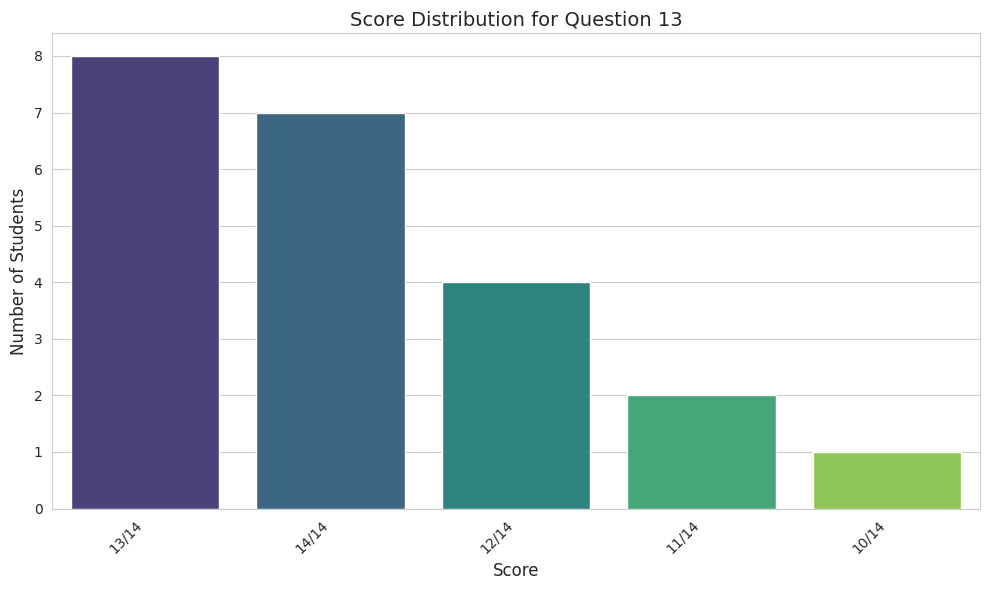

<ipython-input-64-09c70a006f9d>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='question 14 score', data=df_Student_Submissions,


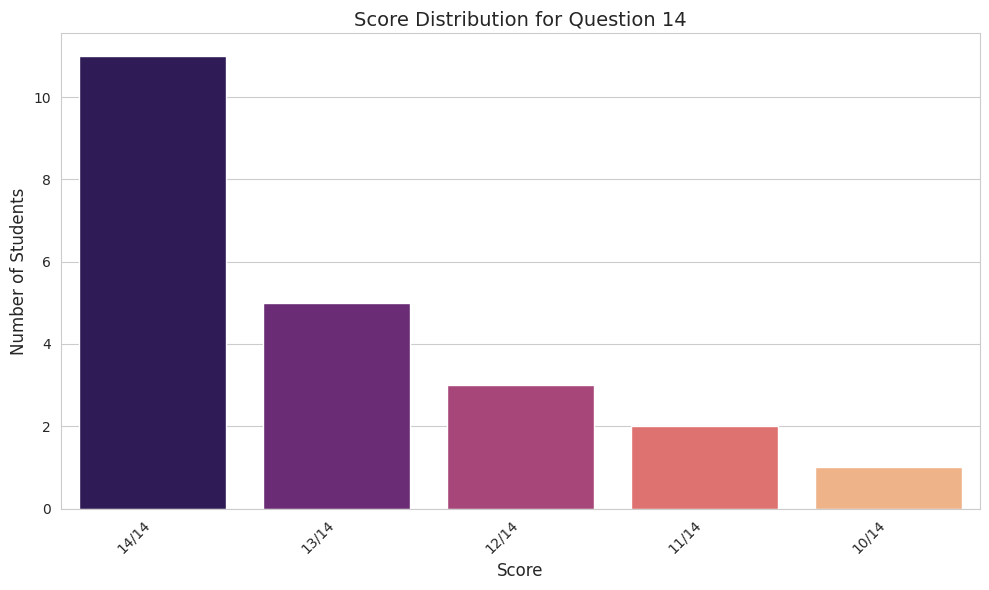

question 13 score
13/14    8
14/14    7
12/14    4
11/14    2
10/14    1
Name: count, dtype: int64
question 14 score
14/14    11
13/14     5
12/14     3
11/14     2
10/14     1
Name: count, dtype: int64


In [ ]:

sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))
sns.countplot(x='question 13 score', data=df_Student_Submissions,
              order=df_Student_Submissions['question 13 score'].value_counts().index,
              palette="viridis")
plt.title('Score Distribution for Question 13', fontsize=14)
plt.xlabel('Score', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))
sns.countplot(x='question 14 score', data=df_Student_Submissions,
              order=df_Student_Submissions['question 14 score'].value_counts().index,
              palette="magma")
plt.title('Score Distribution for Question 14', fontsize=14)
plt.xlabel('Score', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(df_Student_Submissions['question 13 score'].value_counts())
print(df_Student_Submissions['question 14 score'].value_counts())

Statistics for Question 13:
Total Students: 22
Mean Score: 12.82
Median Score: 13.0
Max Score: 14
Min Score: 10
------------------------------
Statistics for Question 14:
Total Students: 22
Mean Score: 13.05
Median Score: 13.5
Max Score: 14
Min Score: 10
------------------------------


<ipython-input-83-9bebd2df3ed8>:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([scores_q13, scores_q14], labels=["Question 13", "Question 14"], patch_artist=True)


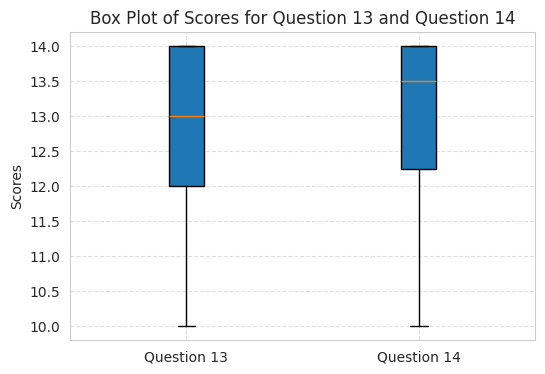

In [ ]:
import numpy as np

def compute_score_statistics(score_dict, question_name):
    scores = []
    for score, count in score_dict.items():
        numeric_score = int(score.split('/')[0])
        scores.extend([numeric_score] * count)


    total_students = sum(score_dict.values())
    mean_score = np.mean(scores)
    median_score = np.median(scores)
    max_score = max(scores)
    min_score = min(scores)

    print(f"Statistics for {question_name}:")
    print(f"Total Students: {total_students}")
    print(f"Mean Score: {mean_score:.2f}")
    print(f"Median Score: {median_score}")
    print(f"Max Score: {max_score}")
    print(f"Min Score: {min_score}")
    print("-" * 30)

    return scores

score_count_q13 = df_Student_Submissions['question 13 score'].value_counts().to_dict()
score_count_q14 = df_Student_Submissions['question 14 score'].value_counts().to_dict()

scores_q13 = compute_score_statistics(score_count_q13, "Question 13")
scores_q14 = compute_score_statistics(score_count_q14, "Question 14")
plt.figure(figsize=(6, 4))
plt.boxplot([scores_q13, scores_q14], labels=["Question 13", "Question 14"], patch_artist=True)
plt.title("Box Plot of Scores for Question 13 and Question 14")
plt.ylabel("Scores")
plt.grid(True, linestyle="--", alpha=0.6)

# Show the plot
plt.show()

There are total of 22 students that answered Q13 and Q14. As for the mean, the mean is slightly higher for Q14 than the average score students achieved for Q13.
A median of 13.5 for Q14 means that at least half of the students scored 13 or higher. The highest possible score (perfect score) was achieved by some students in both questions, which 14. While the minimum score for both questions that student's achieved was a 10.

The scores for 13 seems more towarded to 13/14 and 14/14 whereas 14 has a high count of 11 for 14/14. Let's check the highest count of words in those high scores and the word counts for the additional instructor notes from the df_Question_Details.

In [ ]:

from sklearn.feature_extraction.text import CountVectorizer

def nlp_statistics(text):
  # Assuming df_Question_Details.iloc[0, 1] contains a single string

  vectorizer = CountVectorizer(stop_words='english', max_features=1000)
  X = vectorizer.fit_transform(text)

  word_counts = X.sum(axis=0).A1
  words = vectorizer.get_feature_names_out()

  word_freq = pd.DataFrame({'word': words, 'count': word_counts})
  word_freq = word_freq.sort_values('count', ascending=False)

  print(word_freq.head(10))
  from wordcloud import WordCloud

  wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq.set_index('word')['count'])

  plt.figure(figsize=(10, 6))
  plt.imshow(wordcloud, interpolation='bilinear')
  plt.axis('off')
  plt.show()


             word  count
118           ehr     17
274     processes     12
273       process     11
46            bpr     10
52           care     10
133    enterprise      9
255       patient      9
349       systems      9
186   information      8
31   architecture      8


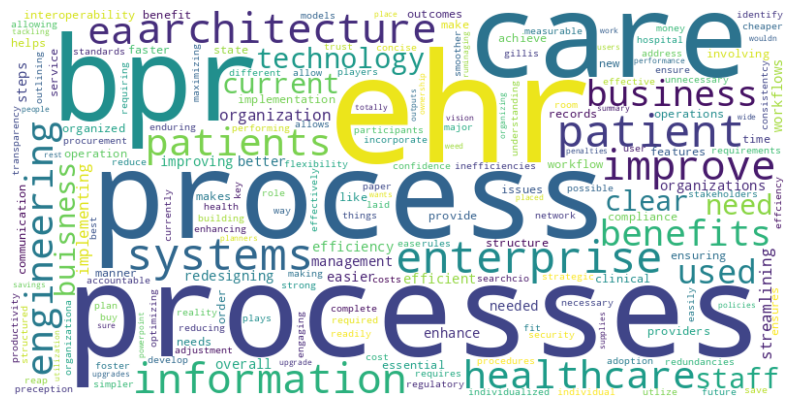

In [ ]:
perfect_score_q13 = df_Student_Submissions[df_Student_Submissions['question 13 score'] == '14/14']['question 13 answer']
nlp_statistics(perfect_score_q13)

We can check the same process for the other dataframe df_Question_Details of the expected answer from the instructor in the row of Question 13 additional instructor notes

In [ ]:
question_13_ans = df_Question_Details.iloc[0,1].split()
question_14_ans = df_Question_Details.iloc[2,1].split()

In [ ]:
question_14_ans

['One',
 'of',
 'the',
 'following.',
 'Other',
 'reasonable',
 'answers',
 'are',
 'also',
 'allowed.',
 '-',
 'Present',
 'and',
 'support',
 'the',
 'current',
 'and',
 'future',
 'vision',
 'of',
 'a',
 'business',
 'and',
 'the',
 'related',
 'As-Is',
 'to',
 'Should-Be',
 'process',
 're-engineering.',
 '-',
 'Support',
 'quality',
 'decision-making',
 'such',
 'as',
 'investment',
 'choices',
 'and',
 'to',
 'manage',
 'the',
 'impact',
 'of',
 'changes',
 'on',
 'the',
 'organization.',
 '-',
 'Optimize',
 'IT',
 'to',
 'support',
 'business',
 'operations',
 'in',
 'a',
 'cost-effective',
 'manner',
 'by',
 'helping',
 'to:',
 'a.',
 'Reduce',
 'redundancy',
 'b.',
 'Reuse',
 'existing',
 'information',
 'and',
 'software',
 'components',
 'c.',
 'Leverage',
 'new',
 'technology',
 'solutions',
 'in',
 'an',
 'EHR',
 'system',
 'effectively',
 'd.',
 'Align',
 'closely',
 'with',
 'an',
 "organization's",
 'mission',
 'and',
 'goals',
 'and',
 'the',
 'goals',
 'of',
 'key',
 

              word  count
15             ehr     10
45       processes     10
37             new      5
62             use      3
38             old      3
4         benefits      3
33        maximize      2
30          longer      2
28     investments      2
25  infrastructure      2


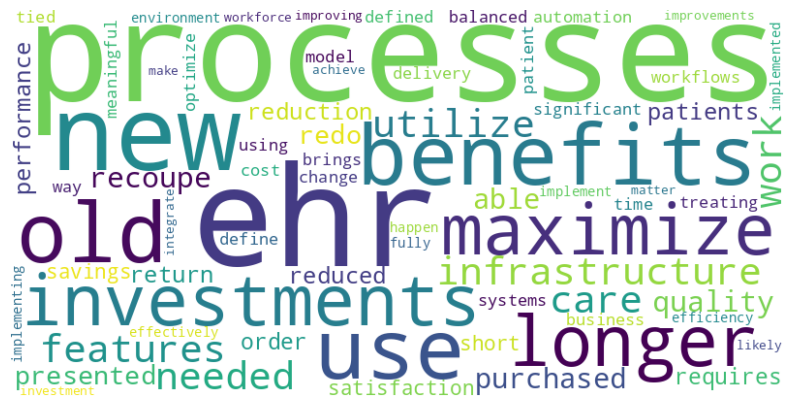

In [ ]:
nlp_statistics(question_13_ans)

We see that the highest word count in the student answers for question 13 where they scored a 14/14 were 'ehr' with 17, 'processes' with 12, and 'process' with 11. Both the terms 'processes' and 'process' are most likely the same meaning in terms of electronic health records information. We see the same case for the expected answer under "additional instructor note", where  highest counts for words were 'ehr' and 'processes', as it was being mentioned under the instructor's answer 10 times.

Let's try the same method for Question 14

           word  count
289     patient     18
61     business     17
125         ehr     17
405     systems     15
53       better     14
57          bpr     13
262         new     13
65         care     11
309   processes     11
174  healthcare     10


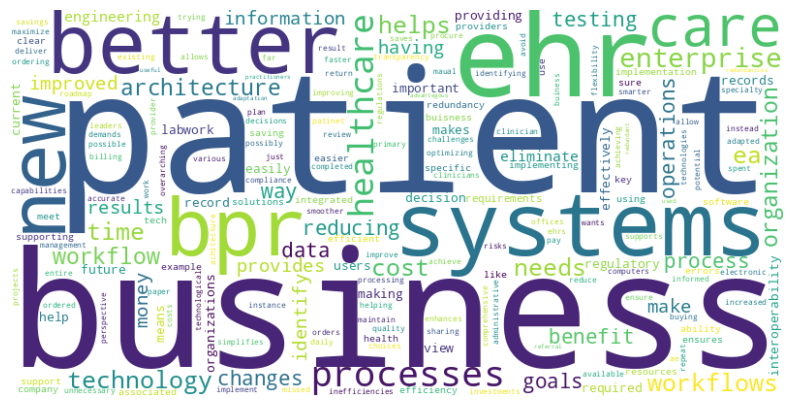

In [ ]:
perfect_score_q14 = df_Student_Submissions[df_Student_Submissions['question 14 score'] == '14/14']['question 14 answer']
nlp_statistics(perfect_score_q14)

             word  count
10       business      6
68     investment      5
136       support      4
45       existing      4
73           like      4
111   procurement      4
97   organization      3
141    technology      3
42     enterprise      3
85        mission      3


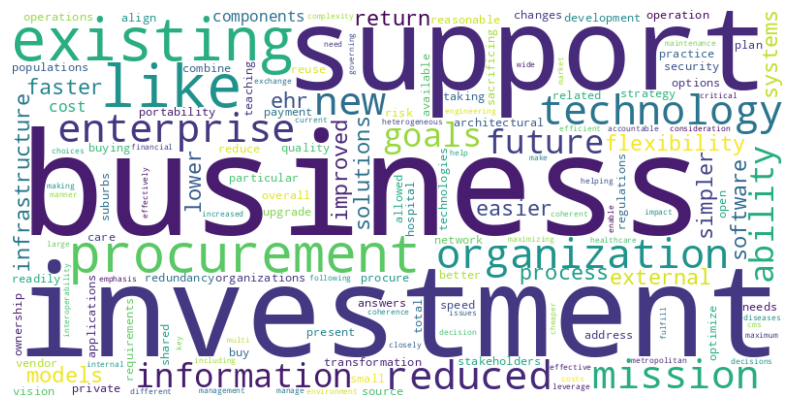

In [ ]:
nlp_statistics(question_14_ans)

Note that we are counting multiple words written by different students who recieved 14/14 for their answer of question 14. So it looks like those students with a 14/14 mentioned 'ehr', and 'patient', as those are terms are mentioned under instructor. Let's check the similarity of the words with TF-IDF vectorizer for question 13 and 14 of each student's score. Before we do that, let's check all the types of scores for each student

In [ ]:
print(df_Student_Submissions['question 13 score'].unique())
print(df_Student_Submissions['question 14 score'].unique())

['12/14' '14/14' '13/14' '10/14' '11/14']
['14/14' '12/14' '13/14' '11/14' '10/14']


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Define the vectorize function
def vectorize(text):
    tfidf_vectorizer = TfidfVectorizer(stop_words='english')

    tfidf_matrix = tfidf_vectorizer.fit_transform(text)
    cosine_similarities = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:])
    return cosine_similarities

# Extract answers for each score
score_14_for_q13 = [df_Question_Details.iloc[0,1]] + df_Student_Submissions[df_Student_Submissions['question 13 score'] == '14/14']['question 13 answer'].tolist()
score_13_for_q13 = [df_Question_Details.iloc[0,1]] + df_Student_Submissions[df_Student_Submissions['question 13 score'] == '13/14']['question 13 answer'].tolist()
score_12_for_q13 = [df_Question_Details.iloc[0,1]] + df_Student_Submissions[df_Student_Submissions['question 13 score'] == '12/14']['question 13 answer'].tolist()
score_11_for_q13 = [df_Question_Details.iloc[0,1]] + df_Student_Submissions[df_Student_Submissions['question 13 score'] == '11/14']['question 13 answer'].tolist()
score_10_for_q13 = [df_Question_Details.iloc[0,1]] + df_Student_Submissions[df_Student_Submissions['question 13 score'] == '11/14']['question 13 answer'].tolist()

def print_cosine_similarities(score_group, score_label):
    cosine_similarities = vectorize(score_group)
    for i, sim in enumerate(cosine_similarities[0]):
        if i == 0:
            continue

        # Get the student name from the DataFrame based on the index (adjusting index by -1 to match the student)
        student_name = df_Student_Submissions.iloc[i-1]['Student']  # Assuming 'Student' is the column for student names
        student_score = df_Student_Submissions.iloc[i-1]['question 13 score']  # Assuming 'score' is the column for student scores

        # Print the student's name, their score, and cosine similarity
        print(f"Student {student_name} (Score: {student_score}) - Cosine Similarity: {sim}")

# Loop through each score group and print cosine similarities for all students
print_cosine_similarities(score_14_for_q13, 14)
print_cosine_similarities(score_13_for_q13, 13)
print_cosine_similarities(score_12_for_q13, 12)
print_cosine_similarities(score_11_for_q13, 11)
print_cosine_similarities(score_10_for_q13, 10)


Student student 1 (Score: 12/14) - Cosine Similarity: 0.24553957706929272
Student student 2 (Score: 14/14) - Cosine Similarity: 0.10314258680668931
Student student 3 (Score: 12/14) - Cosine Similarity: 0.2558611504673173
Student student 4 (Score: 13/14) - Cosine Similarity: 0.026038544730361036
Student student 5 (Score: 14/14) - Cosine Similarity: 0.1572005464380215
Student student 6 (Score: 13/14) - Cosine Similarity: 0.2558611504673173
Student student 1 (Score: 12/14) - Cosine Similarity: 0.14190909587790812
Student student 2 (Score: 14/14) - Cosine Similarity: 0.2342613036967868
Student student 3 (Score: 12/14) - Cosine Similarity: 0.09518107020335595
Student student 4 (Score: 13/14) - Cosine Similarity: 0.07853239145399567
Student student 5 (Score: 14/14) - Cosine Similarity: 0.19306744679431653
Student student 6 (Score: 13/14) - Cosine Similarity: 0.2342613036967868
Student student 7 (Score: 14/14) - Cosine Similarity: 0.03352913080993866
Student student 1 (Score: 12/14) - Cosine 

Now we do the same process for question 14

In [ ]:
score_14_for_q14 = [df_Question_Details.iloc[2,1]] + df_Student_Submissions[df_Student_Submissions['question 14 score'] == '14/14']['question 14 answer'].tolist()
score_13_for_q14 = [df_Question_Details.iloc[2,1]] + df_Student_Submissions[df_Student_Submissions['question 14 score'] == '13/14']['question 14 answer'].tolist()
score_12_for_q14 = [df_Question_Details.iloc[2,1]] + df_Student_Submissions[df_Student_Submissions['question 14 score'] == '12/14']['question 14 answer'].tolist()
score_11_for_q14 = [df_Question_Details.iloc[2,1]] + df_Student_Submissions[df_Student_Submissions['question 14 score'] == '11/14']['question 14 answer'].tolist()
score_10_for_q14 = [df_Question_Details.iloc[2,1]] + df_Student_Submissions[df_Student_Submissions['question 14 score'] == '11/14']['question 14 answer'].tolist()


print_cosine_similarities(score_14_for_q14, 14)
print_cosine_similarities(score_13_for_q14, 13)
print_cosine_similarities(score_12_for_q14, 12)
print_cosine_similarities(score_11_for_q14, 11)
print_cosine_similarities(score_10_for_q14, 10)



Student student 1 (Score: 12/14) - Cosine Similarity: 0.08624361536452185
Student student 2 (Score: 14/14) - Cosine Similarity: 0.21524169301217697
Student student 3 (Score: 12/14) - Cosine Similarity: 0.1278843257512324
Student student 4 (Score: 13/14) - Cosine Similarity: 0.07018925707091467
Student student 5 (Score: 14/14) - Cosine Similarity: 0.05535942151304761
Student student 6 (Score: 13/14) - Cosine Similarity: 0.12010904223605952
Student student 7 (Score: 14/14) - Cosine Similarity: 0.253765934348951
Student student 8 (Score: 13/14) - Cosine Similarity: 0.07018925707091467
Student student 9 (Score: 14/14) - Cosine Similarity: 0.2657159740246558
Student student 10 (Score: 10/14) - Cosine Similarity: 0.1361979540347265
Student student 1 (Score: 12/14) - Cosine Similarity: 0.16720288647802817
Student student 2 (Score: 14/14) - Cosine Similarity: 0.09322757731576264
Student student 3 (Score: 12/14) - Cosine Similarity: 0.14410092442301747
Student student 4 (Score: 13/14) - Cosine 

# Assignment

We notice that students' assignments were in pdf, excel, and pptx format and the grading rubric is in a doc format. We solely focus on just extracting the contents from various data types.

First we will need to install the dependencies to extract the data formats



In [ ]:
!pip install fitz
!pip install python-docx

In [ ]:
import fitz
import re
from collections import Counter
import spacy
from textblob import TextBlob
from docx import Document

nlp = spacy.load("en_core_web_sm")

def extract_text(file_path):
    text = ""

    # Handle PDF files
    if file_path.lower().endswith(".pdf"):
        try:
            doc = fitz.open(file_path)
            for page in doc:
                text += page.get_text("text") + "\n"
        except Exception as e:
            return f"Error extracting text from PDF: {e}"

    # Handle Word (.docx) files
    elif file_path.lower().endswith(".docx") :
        try:
            doc = Document(file_path)  # Use correct variable 'file_path'
            text_list = []

            # Extract text from paragraphs
            for para in doc.paragraphs:
                text_list.append(para.text)

            # Extract text from tables
            for table in doc.tables:
                for row in table.rows:
                    row_text = [cell.text.strip() for cell in row.cells]
                    text_list.append(" | ".join(row_text))  # Join cells with a separator

            text = "\n".join(text_list) if text_list else "No extractable text found."
        except Exception as e:
            return f"Error extracting text from DOCX: {e}"
    elif file_path.lower().endswith(".csv"):
        try:
            df = pd.read_csv(file_path)
            text = df.to_string(index=False)
        except Exception as e:
            return f"Error extracting text from CSV: {e}"

    return text if text.strip() else "No text found."



def nlp_analysis(file_path, top_n=10):
    """Extracts text from a file and performs NLP analysis."""
    text = extract_text(file_path)

    if not text or text.startswith("Error"):  # Handle extraction failure
        print(f"Error: {text}")
        return

    words = re.findall(r'\b\w+\b', text.lower())
    word_counts = Counter(words)
    most_common_words = word_counts.most_common(top_n)

    #NER
    doc_nlp = nlp(text) if text.strip() else None
    named_entities = [(ent.text, ent.label_) for ent in doc_nlp.ents] if doc_nlp else []

    sentiment = TextBlob(text).sentiment if text.strip() else None

    # Format Output
    output = (
        f"Text Sample:\n{text[:500]}\n\n"
        f"Word Frequencies:\n{most_common_words}\n\n"
        f"Named Entities:\n{named_entities}\n\n"
        f"Sentiment Analysis:\n"
        f"   - Polarity: {sentiment.polarity if sentiment else 'N/A'}\n"
        f"   - Subjectivity: {sentiment.subjectivity if sentiment else 'N/A'}\n"
    )

    print(output)



pdf_path = "/content/drive/MyDrive/met_data/Assignment 2 – EHR Functional Requirements Worksheet/24fallmetcs581_m1 submissions and rubrics/student 1/submission.pdf"
nlp_analysis(pdf_path)


Text Sample:
EHR System Functional Requirements Worksheet
Importance
4
Essential -Unacceptabe without this function
3
Important - Critically important function. Not having it would be a major negative
2
Nice - Good to havefunctionality  but could do without it if other functionality is good
1
Optional - Can do without with limited or no impact
Score
4
Fully fulfills this function with flexibility and great fit to  needs
3
Fulfills this function well but with less optional capabilities or flexibility
2
Fulfil

Word Frequencies:
[('and', 56), ('of', 37), ('the', 32), ('to', 28), ('a', 24), ('this', 20), ('4', 18), ('for', 18), ('ehr', 16), ('is', 16)]

Named Entities:
[('EHR System Functional Requirements Worksheet\nImportance', 'ORG'), ('4', 'CARDINAL'), ('3', 'CARDINAL'), ('2', 'CARDINAL'), ('1', 'CARDINAL'), ('4', 'CARDINAL'), ('3', 'CARDINAL'), ('2', 'CARDINAL'), ('1', 'CARDINAL'), ('0', 'CARDINAL'), ('Function\nImportance\nVendor Score', 'ORG'), ('Notes', 'PRODUCT'), ('two', 'CARDIN

The output summarizes the NLP analysis of a PDF document containing EHR system requirements. The text sample provides the first 500 characters, describing the scoring system for EHR functionality. The word frequency analysis highlights commonly used terms such as "EHR," "function," and numerical scores, indicating a structured evaluation framework. The named entity recognition (NER) identifies key organizations like CMS and VWC, medical systems such as CPOE and CDS, and numerical values like 30%, which help in understanding the document’s key concepts. Lastly, the sentiment analysis reveals a slightly positive tone (polarity = 0.19) and moderate subjectivity (0.48), suggesting that the document contains both factual content and evaluative language. It looks like this document is just EHR system requirements for student's to follow.

Now let's for a word or doc document to know if we can perform the same process above.

In [ ]:
doc_path = "/content/drive/MyDrive/met_data/Assignment 2 – EHR Functional Requirements Worksheet/CS581 Assignment 2 HIS Clinical (EHR) Functional Requirements Grading Rubric -2025 Spring 1.docx"
nlp_analysis(doc_path)

Text Sample:


Learning Objective | Grades Achieved | Criteria for Grading and Feedback
Understanding of HIS Clinical (EHR) capabilities.  What an EHR does.  
Identification of key EHR functions as defined in the lecture and textbook. 
(45 points) | 95-100 (45 pts)
90-94 (42 pts)
85-89 (40 pts)
80-84 (38 pts)
75-79 (36 pts)
70-74 (33 pts)
65-69 (31 pts)
60-64 (29 pts)
55-59 (27 pts) | Feedback:
Work shows good understanding of EHR and functional requirements.
Work shows identified functions relate to Virgini

Word Frequencies:
[('pts', 18), ('and', 12), ('of', 11), ('functions', 11), ('the', 9), ('other', 7), ('ehr', 6), ('points', 6), ('feedback', 5), ('are', 5)]

Named Entities:
[('Grades Achieved', 'PERSON'), ('Criteria for Grading and Feedback\nUnderstanding of HIS Clinical', 'ORG'), ('45', 'CARDINAL'), ('95-100', 'CARDINAL'), ('45', 'CARDINAL'), ('90-94', 'CARDINAL'), ('42', 'CARDINAL'), ('85-89', 'DATE'), ('40', 'CARDINAL'), ('80', 'CARDINAL'), ('38', 'CARDINAL'), ('75-79', 'CARD

Our primary goal was to able to extract various assignments despite of data formats such as pdf or doc format in order for the LLM to ingest the textual data from either formats. As for the doc short analysis, the output presents the results of an NLP analysis on a document related to EHR (Electronic Health Record) functional requirements. The **Text Sample** shows an excerpt from the document, highlighting grading criteria and feedback on understanding EHR capabilities. The **Word Frequencies** section lists the most common words, with "pts" (points) being the most frequent, likely due to the grading rubric. The **Named Entities** section identifies key terms, classifying numbers like "45" and "95-100" as **CARDINAL** (numerical values), while organizations such as "Virginia Women Center’s" and "MIPS" (Merit-based Incentive Payment System) are labeled as **ORG**. Some misclassifications, like "Meaningful Use" being tagged as **PERSON**, indicate that the model may need context adjustments. Finally, the **Sentiment Analysis** reveals a **slightly positive polarity (0.1038)**, meaning the text has a mildly positive tone, and a **moderate subjectivity (0.4719)**, suggesting a mix of factual content and subjective opinions, likely from the feedback provided. Overall, the analysis provides insights into the structure, key entities, and tone of the document.

In [ ]:
pdf_path_lec = "/content/drive/MyDrive/met_data/Lecture Material/Module 1 Lecture Materials.pdf"
nlp_analysis(pdf_path_lec)

Text Sample:
Readings:
Amatayakul, Chapters 1 and 5
Updated HIMSS Davies Award Winner Virginia Women’s Health
Center Application (posted on course Blackboard discussion
forum)
Review - ONC Workflow Tools
Review - AHRQ Toolkit on Workflow Assessment and Re-design
Optional – More Detail on Business Process Re-engineering
Recent article – will be posted in the Live Classroom Slides and
Materials discussion forum
Assignments:
Assignment 1 due Tuesday, January 23 at 6:00 AM ET
Assessments:
Quiz 1 due Tuesday, Jan

Word Frequencies:
[('the', 392), ('and', 245), ('of', 216), ('to', 165), ('a', 156), ('in', 118), ('ehr', 106), ('is', 105), ('an', 94), ('process', 92)]

Named Entities:
[('Amatayakul', 'ORG'), ('Chapters 1', 'DATE'), ('Blackboard', 'PERSON'), ('Optional', 'ORG'), ('the Live Classroom Slides', 'ORG'), ('1', 'CARDINAL'), ('Tuesday, January 23', 'DATE'), ('6:00 AM', 'TIME'), ('Quiz 1', 'PRODUCT'), ('Tuesday, January 23', 'DATE'), ('6:00 AM', 'TIME'), ('Tuesday, January 23', 'DATE')

In [ ]:
csv_path = "/content/drive/MyDrive/met_data/Assignment 2 – EHR Functional Requirements Worksheet/additional submissions (no feedback)/Student 1/Sample1_Assignment.csv"
nlp_analysis(csv_path)

Text Sample:
    EHR System Functional Requirements Worksheet Unnamed: 1                                                                               Unnamed: 2                                                                                                                                                                                                                                                                                                                                                                

Word Frequencies:
[('nan', 64), ('is', 25), ('this', 23), ('a', 16), ('4', 14), ('to', 14), ('vwh', 14), ('it', 13), ('i', 13), ('chose', 13)]

Named Entities:
[('3', 'CARDINAL'), ('NaN        NaN                                                                                      NaN', 'FAC'), ('NaN', 'GPE'), ('NaN        NaN                                                                                      NaN', 'FAC'), ('NaN', 'GPE'), ('NaN', 'GPE'), ('NaN', 'GPE'), ('3      

The extracted text from an EHR System Functional Requirements Worksheet contains many NaN values, affecting analysis. As for word frequency highlights repetitive terms, while NER identifies organizations like VWH and MIPS, but misclassifies some missing data. Sentiment analysis shows a slightly positive tone 0.23 polarity with moderate subjectivity 0.58, indicating a mix of facts and opinions.

## Exploring different modalities of the Data

Some student submissions are in different modalities like a powerpoint submission or other visual data. In this section we explore the ability of OpenAI's vision models to interpret this visual data.

In [ ]:
# Imports for this section
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
from openai import OpenAI
from getpass import getpass
from IPython.display import Markdown

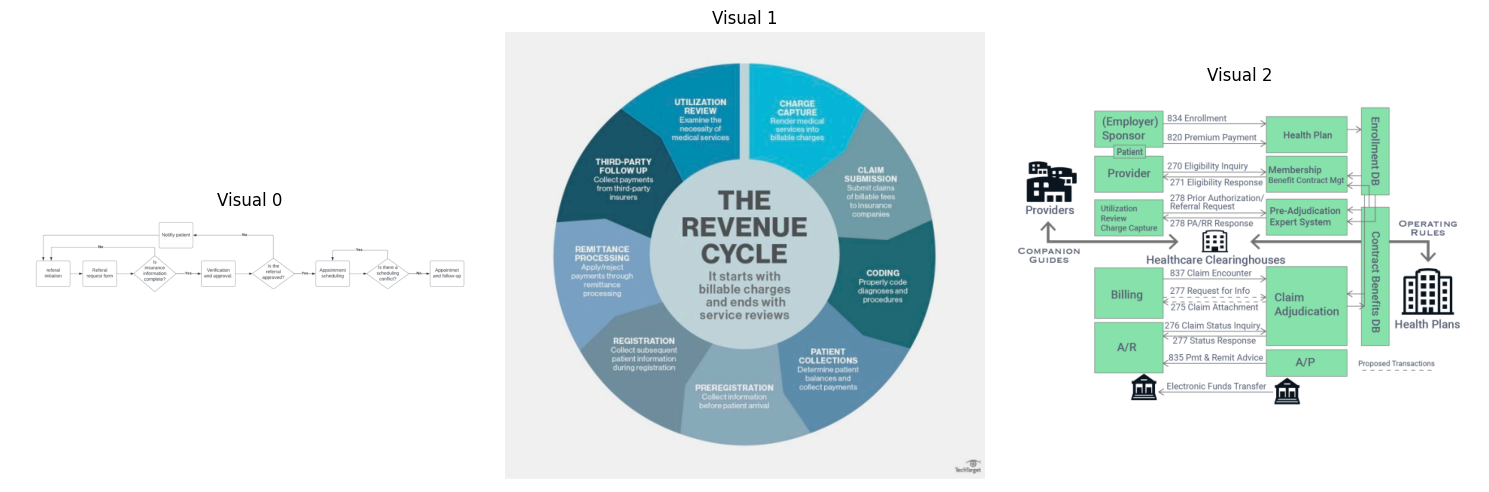

In [ ]:
# Google Drive direct download links
module_3_lecture_diagram_medium = 'https://nc.aseef.dev/s/ckKjGSNKRi2HssF/preview'
module_3_lecture_diagram_hard = 'https://nc.aseef.dev/s/BFK9Eqmjot7SMrK/preview'
student3_chart_url_easy = 'https://nc.aseef.dev/s/7HBJpJXbHJsjkxD/preview' # this is a student response from assignment 1

# List of URLs
image_urls = [student3_chart_url_easy, module_3_lecture_diagram_medium, module_3_lecture_diagram_hard]

# Download and store images
images = []
for url in image_urls:
    response = requests.get(url)
    if response.status_code == 200:
        img = Image.open(BytesIO(response.content))
        images.append(img)
    else:
        print(f"Failed to download image from {url}")

# Display all images
fig, axes = plt.subplots(1, len(images), figsize=(15, 5))

for ax, img, idx in zip(axes, images, range(0, len(images))):
    ax.imshow(img)
    ax.axis("off")  # Hide axes
    ax.set_title(f"Visual {idx}")

plt.tight_layout()
plt.show()


In [9]:
oai_api_key = getpass("Enter your OpenAI API Key: ")

Enter your OpenAI API Key: ··········


In [ ]:
client = OpenAI(api_key = oai_api_key)

responses = []

for url in image_urls:
  response = client.chat.completions.create(
  model="gpt-4o",
  messages=[
    {
      "role": "system",
      "content": [
        {
          "type": "text",
          "text": "Your goal is to convert visual information into text with minimal loss of information. Describe what you see in as much detail as possible. Describe how the components of the image you see are related to one another? For example, if you see a graph or a chart, which nodes are connected to what? What appears to be the root node? Any text you see in the image should be included verbatim missing no information."
        }
      ]
    },
    {
      "role": "user",
      "content": [
        {
          "type": "image_url",
          "image_url": {
            "url": url
          }
        }
      ]
    }
  ],
  response_format={
    "type": "text"
  },
  temperature=1,
  max_completion_tokens=5000,
  top_p=1,
  frequency_penalty=0,
  presence_penalty=0
  )
  responses += [response.choices[0].message.content]

In [ ]:
# Display formatted Markdown
display(Markdown(responses[0]))

The flowchart depicts a process for handling referrals in the context of healthcare services. Here’s a breakdown of the steps:

1. **Referral Initiation**: The process begins with referral initiation.

2. **Referral Request Form**: 
   - After initiation, a referral request form is completed.

3. **Is Insurance Information Complete?**: 
   - If "No," return to the referral request form.
   - If "Yes," proceed to verification and approval.

4. **Verification and Approval**: 
   - The process moves to verification and approval of the referral.

5. **Is the Referral Approved?**: 
   - If "No," notify the patient.
   - If "Yes," proceed to appointment scheduling.

6. **Appointment Scheduling**: 
   - The referral is processed for scheduling an appointment.

7. **Is There a Scheduling Conflict?**: 
   - If "Yes," return to appointment scheduling.
   - If "No," proceed to appointment and follow-up.

8. **Appointment and Follow-Up**: 
   - The process concludes with appointment and follow-up.

The flowchart includes loops to ensure information completeness, approval, and scheduling without conflicts, leading to patient notification or completion of appointments.

**Thoughts:** Impressive. OpenAI 4o model accurately explained the aspects of the flowchart that were present. It did not miss any detail. This is a promising start. At the same time it should be noted that this is a relatively simple and straightforward diagram. Lets see if it can handled something more complex...

In [ ]:
# Display formatted Markdown
display(Markdown(responses[1]))

The image is a circular diagram illustrating "The Revenue Cycle" in healthcare. It highlights the different stages, starting with billable charges and ending with service reviews. The cycle includes the following steps:

1. **Utilization Review**: Examine the necessity of medical services.
2. **Charge Capture**: Render medical services into billable charges.
3. **Claim Submission**: Submit claims of billable fees to insurance companies.
4. **Coding**: Properly code diagnoses and procedures.
5. **Patient Collections**: Determine patient balances and collect payments.
6. **Preregistration**: Collect information before patient arrival.
7. **Registration**: Collect subsequent patient information during registration.
8. **Remittance Processing**: Apply/reject payments through remittance processing.
9. **Third-Party Follow Up**: Collect payments from third-party insurers.

The center of the circle states: "THE REVENUE CYCLE. It starts with billable charges and ends with service reviews." 

The diagram is segmented into equal parts, each representing a step in the cycle, and is visually divided by different shades of blue and teal.

**Thoughts:** Interesting. It missed a rather subtle aspect of the chart which is *charge capture should come first*. With that said it did recognize everything else. But now the real question is, what about even harder? The next chart has text that corresponds to different parts of the diagram very close. Its hard for even a human to tell. Lets see how they AI handles this...

In [ ]:
display(Markdown(responses[2]))

The diagram illustrates the flow of transactions and communication within a healthcare system involving various entities and processes. Here's a detailed breakdown:

### Entities Involved

1. **Providers**
   - Displayed as buildings on the left labeled "Providers."

2. **Healthcare Clearinghouses**
   - Centered in the diagram with interactions with various entities.

3. **Health Plans**
   - Displayed as a building on the right labeled "Health Plans."

4. **Databases**
   - Enrollment DB
   - Contract Benefits DB

5. **Financial Entities**
   - A/R (Accounts Receivable)
   - A/P (Accounts Payable)

### Key Processes and Transactions

1. **Employer/Patient (Top Left)**
   - **834 Enrollment**: From (Employer) Sponsor to Health Plan.
   - **820 Premium Payment**: From (Employer) Sponsor to Health Plan.

2. **Provider Transactions**
   - **270 Eligibility Inquiry**: From Provider to Membership/Benefit Contract Management.
   - **271 Eligibility Response**: From Membership/Benefit Contract Management to Provider.
   - **278 Prior Authorization/Referral Request**: From Provider to Pre-Adjudication Expert System.
   - **278 PA/RR Response**: From Pre-Adjudication Expert System to Provider.
   - Providers use "Utilization Review Charge Capture."

3. **Healthcare Clearinghouses (Center)**
   - Deals with claims and transaction status.
   - **837 Claim Encounter**: From Providers to Claim Adjudication.
   - **277 Request for Info** and **275 Claim Attachment**: Managed by Billing.
   - **276 Claim Status Inquiry** and **277 Status Response**: Communication between Providers and Claim Adjudication.
   - **835 Pmt & Remit Advice**: From A/P to A/R via Electronic Funds Transfer.

4. **Databases and Expert Systems**
   - **Enrollment DB** and **Contract Benefits DB** interact with Health Plan processes and Membership/Benefit Contract Management.
   - Pre-Adjudication Expert System aids in managing prior authorization/referral responses.

5. **Electronic Funds Transfer**
   - Facilitates transactions between A/R and A/P.

### Companion Guides and Operating Rules
- **Companion Guides**: Assist with the transaction processes between Providers and Healthcare Clearinghouses.
- **Operating Rules**: Govern interactions with Health Plans.

Overall, the diagram provides a comprehensive overview of how data and financial transactions flow through a healthcare system, involving employers, health plans, providers, and clearinghouses, supported by databases and expert systems.

**Thoughts:** Hmm, as expected the LLM did misassociate and misrepresent parts of the chart. For example "Databases" aren't a seperate entity of their own. At the same time, it also was impressive and recognizing the involving of "Finanicial entities". Honestly this chart is confusing even too me, so I'm tempted to give the LLM a break because I don't funny understand it either 😂.

## Exploring rubric generation/augmentation using LLMs

In [ ]:
import openai

# Prompt the user to enter their OpenAI API key securely
api_key = getpass("Enter your OpenAI API Key: ")
openai.api_key = api_key

def create_structured_rubric(rubric_text):
    # Define the prompt asking for a structured version of the rubric
    prompt = (
        "You are assisting a professor who is using LLMs to grade homework assignments. Your objective is to take in content or a pre written rubric,"
        "and reword it in such a way that an LLM can consistently grade using it. It should be clear and have good structure. It should also be very comprehensive"
        "and should aim to have the LLM take off points consistently for the same infraction."
        "Please transform the following rubric into a more structured format. "
        "Ensure that the final output is clearly organized with headings, bullet points, "
        "and any other formatting that improves clarity. You are also provided with sample solutions and scores. \n\n"
        "Rubric:\n"
        f"{rubric_text}\n\n"
        "Structured Rubric:"
    )

    # Use the ChatCompletion API with a system prompt for context
    response = openai.chat.completions.create(
        model="gpt-4o",  # or another available chat model
        messages=[
            {"role": "system", "content": "You are a helpful assistant."},
            {"role": "user", "content": prompt}
        ],
        max_tokens=1000,      # adjust based on the expected output length
        temperature=0.7      # adjust for creativity or determinism
    )

    # Extract and return the structured rubric text
    structured_rubric = response.choices[0].message.content.strip()
    return structured_rubric

# Example usage:
rubric_text = '''Short Answer Question: What is one benefit of using an Enterprise Architecture and why is it a benefit? Note that the students are instructed to only provide one benefit. So the credit lies on how detailed they are with explaining that one benefit, instead of listing all different types of benefits.

Sample Answer #1: When we look at the benefits from an IT operation standpoint, designed a solid enterprise architecture leads to an overall more efficient IT operation by reducing software development and maintenance costs. EA's significantly improve the interoperability and simplification of the systems used and the network management, allowing different systems to be used in conjunction and communicate effectively.
Manual Scoring: 14 out of 14 points


Well though out EA's can also enhance organizations in addressing issues such as security by allowing protocols and policies that can be used enterprise wide. This also means it is easier to upgrade and and exchange system components easily without disruptions in the overall infrastructure of the system, going back to the concept of EA's ability to improve interoperability and simplifications of systems being used.

Sample Answer #2: One benefit of using an Enterprise Architecture is it improves IT operations, so they are more efficient. This is beneficial because development, support, and maintenance costs for software is cheaper, system and network management is easier, and it is easier to upgrade and exchange system components. EA also improves interoperability, ability to address critical issues (such as security), and portability of applications.
Manual Scoring: 12 out of 14 points


Sample Answer #3: It helps use information technology to support business operations in a cost effective manner. It does that by reducing redundancy and leveraging new technology solutions effectively.
Manual Scoring: 10 out of 14 points

Grading Rubric
Other reasonable answers are also allowed.

- Present and support the current and future vision of a business and the related As-Is to Should-Be process re-engineering.
- Support quality decision-making such as investment choices and to manage the impact of changes on the organization.
- Optimize IT to support business operations in a cost-effective manner by helping to:
a. Reduce redundancy
b. Reuse existing information and software components
c. Leverage new technology solutions in an EHR system effectively
d. Align closely with an organization's mission and goals and the goals of key stakeholders, both internal and external to the enterprise.

- Combine the technology, systems, business and market options to fulfill the enterprise mission, taking into consideration the:
a. External environment—Like the ARRA and HighTech Act
b. Mission of the healthcare organization—A large, metropolitan teaching hospital has different needs from a small private practice in the suburbs.
c. Business strategy (such as emphasis on particular populations or diseases )
d. Business models (e.g., transformation to shared financial risk business models like accountable care organizations)
e. Technology (including existing and new technologies like an EHR

- Help enable a more efficient IT Operation:
a. Lower software development, support, and maintenance costs
b. Increased portability of applications
c. Improved interoperability and easier system and network management
d. Improved ability to address critical enterprise-wide issues like security
e. Easier upgrade and exchange of system components

- Better return on existing investment and reduced need for future investment:
a. Reduced complexity in the IT infrastructure
b. Maximum return on investment in the existing IT infrastructure
c. The flexibility to make, buy, or out-source IT solutions
d. Reduced overall new investment lower total cost of IT ownership

- Faster, simpler, and cheaper procurement:
a. Buying decisions are simpler, because the information governing procurement is readily available in a coherent plan.
b. The procurement process is faster—maximizing procurement speed and flexibility without sacrificing architectural coherence.
c. The ability to procure heterogeneous, multi-vendor, open systems.


'''

structured_rubric = create_structured_rubric(rubric_text)
print("Structured Rubric:\n", structured_rubric)


Enter your OpenAI API Key: ··········
Structured Rubric:
 # Structured Grading Rubric for Short Answer Question

## Task
- **Question**: What is one benefit of using an Enterprise Architecture and why is it a benefit?
- **Note**: Students should only provide one benefit. The emphasis is on the depth and detail of the explanation for that single benefit.

## Scoring Criteria

### 1. Explanation of the Benefit (0-6 Points)
- **Detailed Explanation**: The student provides a comprehensive and detailed explanation of the chosen benefit. (5-6 Points)
- **Moderate Explanation**: The explanation of the benefit is clear but lacks depth or detail. (3-4 Points)
- **Basic Explanation**: The explanation is vague or lacks clarity. (1-2 Points)
- **No Explanation**: The benefit is mentioned without any explanation. (0 Points)

### 2. Relevance and Accuracy (0-4 Points)
- **Highly Relevant and Accurate**: The benefit is clearly relevant to Enterprise Architecture, and the explanation is accurate and p

We are experimenting with using an LLM to make a more tailored rubric than what we currently have, which will hopefully lead to more consistent and precise grading. Here is an example of doing so. We took a provided rubric and sample solutions from quiz 1 and strategically prompted the LLM to create a new rubric that is better structured and follows more specifications. Ideally, the prompt for grading will be as precise as possible and cover many edge cases, such as "Take into account only the content of the response and not the grammar." This output we have here already provides a step forward from the current rubric, which is simply just a list of acceptable responses that provides no guidance on how to distribute credit which can lead to grading inconsistencies. This rubirc provides specific point allotments and describes what warrants each point range.